# 02. 확장 실습: 병렬 쇼핑 검색 Agent

---

## 학습 목표

**관련도 / 가격 낮은순 / 가격 높은순** 으로 3가지 검색을 **동시에 실행**하고,  
결과를 통합해 균형 잡힌 추천을 제공하는 에이전트를 만듭니다.

## 그래프 구조: Fan-out / Fan-in

```text
           ┌→ [관련도검색] ─┐
START ─────┼→ [가격순검색] ─┼→ [통합&랭킹] → [추천생성] → END
           └→ [고급검색]  ─┘
           (3개 병렬 실행)    (fan-in: 모두 완료 후 실행)
```

## 핵심 개념: `Annotated` 리듀서

```python
from typing import Annotated
import operator

class State(TypedDict):
    # 병렬 노드들이 각자 반환하는 리스트가 자동으로 합산됨
    all_products: Annotated[List[dict], operator.add]
```

| 노드 | 반환 | all_products 결과 |
|---|---|---|
| 관련도검색 | `{"all_products": [A, B, C]}` | [A, B, C] |
| 가격순검색 | `{"all_products": [D, E, F]}` | [A, B, C, D, E, F] |
| 고급검색  | `{"all_products": [G, H, I]}` | [A, B, C, D, E, F, G, H, I] |

In [1]:
from dotenv import load_dotenv
load_dotenv(override=True, dotenv_path="../.env")

import os
import re
import requests
import operator
from html import unescape
from typing import TypedDict, List, Annotated

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# LLM 모델 초기화
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
print("준비 완료")

준비 완료


In [2]:
def search_naver_shopping(query: str, display: int = 5, sort: str = "sim") -> list[dict]:
    """
    네이버 쇼핑 API로 상품을 검색한다.
    sort: sim(관련도), asc(낮은가격), dsc(높은가격)
    """
    url = "https://openapi.naver.com/v1/search/shop.json"

    # API 인증 헤더 설정
    headers = {
        "X-Naver-Client-Id":     os.environ["NAVER_CLIENT_ID"],
        "X-Naver-Client-Secret": os.environ["NAVER_CLIENT_SECRET"],
    }

    # 검색 파라미터 설정
    params = {"query": query, "display": display, "start": 1, "sort": sort}

    # API 호출
    resp = requests.get(url, headers=headers, params=params, timeout=10)
    resp.raise_for_status()  # HTTP 오류 시 예외 발생

    # 응답에서 상품 목록 추출
    result = []
    for item in resp.json().get("items", []):
        # HTML 태그와 특수문자 제거 (예: <b>상품명</b> → 상품명)
        clean_title = re.sub(r"<[^>]+>", "", unescape(item.get("title", "")))
        result.append({
            "title":    clean_title,
            "link":     item.get("link", ""),
            "lprice":   int(item.get("lprice", 0) or 0),  # 최저가 (없으면 0)
            "mall":     item.get("mallName", ""),
            "brand":    item.get("brand", ""),
            "category": item.get("category1", ""),
        })
    return result

print("API 래퍼 정의 완료")

API 래퍼 정의 완료


---

## Step 1. State 정의

`Annotated[List[dict], operator.add]` 를 사용하면  
병렬 노드들이 반환하는 리스트가 **자동으로 합산**됩니다.

In [3]:
class ParallelShoppingState(TypedDict):
    query:           str                                  # 검색어 (입력)
    all_products:    Annotated[List[dict], operator.add]  # 병렬 검색 결과 자동 합산
    ranked_products: List[dict]                           # 중복 제거 + 정렬 후
    recommendation:  str                                  # 최종 추천 (출력)

print("State 필드:", list(ParallelShoppingState.__annotations__.keys()))
print()
print("※ all_products: Annotated[List, operator.add]")
print("  → 병렬 노드 3개가 각자 반환한 리스트가 자동으로 이어 붙여집니다.")

State 필드: ['query', 'all_products', 'ranked_products', 'recommendation']

※ all_products: Annotated[List, operator.add]
  → 병렬 노드 3개가 각자 반환한 리스트가 자동으로 이어 붙여집니다.


---

## Step 2. 병렬 검색 노드 3개

같은 쿼리를 **다른 정렬 기준**으로 동시에 검색합니다.

In [4]:
# ── 병렬 노드 1: 관련도순 검색 (기본값) ─────────────────────
def search_by_relevance(state: ParallelShoppingState) -> dict:
    """관련도 높은 상품 검색 (sort=sim)"""
    results = search_naver_shopping(state["query"], display=5, sort="sim")
    print(f"  [관련도검색] {len(results)}개")
    return {"all_products": results}   # operator.add로 자동 합산


# ── 병렬 노드 2: 가격 낮은순 검색 ──────────────────────────
def search_by_price(state: ParallelShoppingState) -> dict:
    """가격이 낮은 상품 검색 (sort=asc)"""
    results = search_naver_shopping(state["query"], display=5, sort="asc")
    print(f"  [가격순검색] {len(results)}개")
    return {"all_products": results}   # operator.add로 자동 합산


# ── 병렬 노드 3: 가격 높은순 검색 ──────────────────────────
def search_by_premium(state: ParallelShoppingState) -> dict:
    """프리미엄(고가) 상품 검색 (sort=dsc)"""
    results = search_naver_shopping(state["query"], display=5, sort="dsc")
    print(f"  [고급검색]   {len(results)}개")
    return {"all_products": results}   # operator.add로 자동 합산


print("병렬 검색 노드 3개 정의 완료")

병렬 검색 노드 3개 정의 완료


In [5]:
# ── 통합&랭킹 노드 ───────────────────────────────────────────
def merge_and_rank_node(state: ParallelShoppingState) -> dict:
    """
    3개 검색 결과(all_products)를 통합한다:
    1) URL 기준 중복 제거
    2) 가격 낮은순으로 재정렬
    3) 상위 9개 선택
    """
    # operator.add 리듀서에 의해 이미 3개 결과가 합산된 상태
    all_products = state["all_products"]
    print(f"  [통합&랭킹] 합산 {len(all_products)}개 → 중복 제거 중...")

    # URL 기준으로 중복 제거
    seen   = set()
    unique = []
    for p in all_products:
        # 링크가 처음 등장하고 가격이 0보다 큰 상품만 추가
        if p["link"] not in seen and p["lprice"] > 0:
            seen.add(p["link"])
            unique.append(p)

    # 가격 낮은순 정렬 후 상위 9개 선택
    ranked = sorted(unique, key=lambda x: x["lprice"])[:9]
    print(f"  [통합&랭킹] 중복 제거 후: {len(unique)}개 → 상위 {len(ranked)}개 선택")
    return {"ranked_products": ranked}


# ── 추천생성 노드 ────────────────────────────────────────────
# 가격 티어별 추천을 생성하는 프롬프트
recommend_prompt = ChatPromptTemplate.from_messages([
    ("system", """아래 네이버 쇼핑 검색 결과(관련도·가격순·고급 3가지 기준 통합)를 바탕으로
사용자에게 맞춤 상품을 추천하세요.

## 🛍️ 쇼핑 추천 결과

### 💸 가성비 추천 (저가)
### ⚖️  균형 추천 (중가)
### 👑 프리미엄 추천 (고가)

각 티어마다 상품명, 가격, 쇼핑몰, 링크를 포함하세요."""),
    ("human", "검색어: {query}\n\n통합 상품 목록:\n{products}")
])

def recommend_node(state: ParallelShoppingState) -> dict:
    """통합된 상품으로 가격 티어별 추천을 생성한다"""
    print("  [추천생성] 티어별 추천 작성 중...")

    # 상품 목록을 LLM이 읽기 쉬운 텍스트로 변환
    lines = []
    for i, p in enumerate(state["ranked_products"]):
        line = f"[{i+1}] {p['title'][:45]} | {p['lprice']:,}원 | {p['mall']} | {p['link']}"
        lines.append(line)
    products_text = "\n".join(lines)

    # 체인 정의: 프롬프트 → LLM → 텍스트 파서
    chain = recommend_prompt | llm | StrOutputParser()

    # 체인 실행: 검색어와 상품 목록을 넣어 추천 생성
    answer = chain.invoke({
        "query":    state["query"],
        "products": products_text
    })

    print("  [추천생성] 완료")
    return {"recommendation": answer}


print("통합·추천 노드 정의 완료")

통합·추천 노드 정의 완료


---

## Step 3. 그래프 조립: Fan-out / Fan-in

```python
# Fan-out: START → 3개 노드 동시 실행
builder.add_edge(START, "관련도검색")
builder.add_edge(START, "가격순검색")
builder.add_edge(START, "고급검색")

# Fan-in: 3개 노드 → 하나로 수렴 (모두 완료 후 실행)
builder.add_edge("관련도검색", "통합&랭킹")
builder.add_edge("가격순검색", "통합&랭킹")
builder.add_edge("고급검색",   "통합&랭킹")
```

In [8]:
# 그래프 빌더 생성
builder = StateGraph(ParallelShoppingState)

# 노드 등록
builder.add_node("관련도검색", search_by_relevance)
builder.add_node("가격순검색", search_by_price)
builder.add_node("고급검색",   search_by_premium)
builder.add_node("통합&랭킹",  merge_and_rank_node)
builder.add_node("추천생성",   recommend_node)

# ── Fan-out: START → 3개 노드 동시 실행 ──────────────────────
builder.add_edge(START, "관련도검색")
builder.add_edge(START, "가격순검색")
builder.add_edge(START, "고급검색")

# ── Fan-in: 3개 노드 → 통합 (모두 완료 후 실행) ──────────────
builder.add_edge("관련도검색", "통합&랭킹")
builder.add_edge("가격순검색", "통합&랭킹")
builder.add_edge("고급검색",   "통합&랭킹")

# 순차 연결
builder.add_edge("통합&랭킹", "추천생성")
builder.add_edge("추천생성",  END)

# 그래프 컴파일
parallel_app = builder.compile()
print("그래프 컴파일 완료")

그래프 컴파일 완료


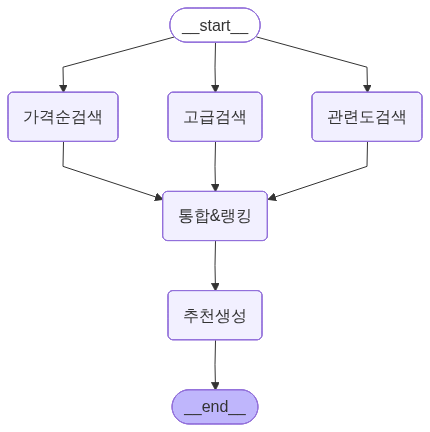

In [7]:
try:
    display(Image(parallel_app.get_graph().draw_mermaid_png()))
except:
    print(parallel_app.get_graph().draw_ascii())

---

## Step 4. 실행

In [9]:
def run_parallel_search(query: str):
    print(f"\n{'='*60}")
    print(f"검색어: {query}")
    print('='*60)

    # 초기 State를 넣어 그래프 실행
    result = parallel_app.invoke({
        "query":           query,
        "all_products":    [],
        "ranked_products": [],
        "recommendation":  ""
    })

    print(f"\n[수집 상품] 총 {len(result['all_products'])}개 "
          f"→ 중복 제거 후 {len(result['ranked_products'])}개")
    print(f"\n{result['recommendation']}")


run_parallel_search("무선 이어폰")


검색어: 무선 이어폰
  [가격순검색] 5개
  [고급검색]   5개
  [관련도검색] 5개
  [통합&랭킹] 합산 15개 → 중복 제거 중...
  [통합&랭킹] 중복 제거 후: 15개 → 상위 9개 선택
  [추천생성] 티어별 추천 작성 중...
  [추천생성] 완료

[수집 상품] 총 15개 → 중복 제거 후 9개

무선 이어폰을 찾고 계신다면, 아래의 추천 상품을 확인해 보세요. 각 티어별로 가성비, 균형, 프리미엄 상품을 소개합니다.

### 💸 가성비 추천 (저가)
- **상품명:** 로랜텍 커널형 버즈 무선 블루투스 이어폰 RSM-R510  
  **가격:** 19,800원  
  **쇼핑몰:** 네이버  
  **링크:** [구매하기](https://search.shopping.naver.com/catalog/53530143052)

### ⚖️ 균형 추천 (중가)
- **상품명:** 베이스어스 BP1 PRO 노이즈캔슬링 이어폰  
  **가격:** 28,900원  
  **쇼핑몰:** 네이버  
  **링크:** [구매하기](https://search.shopping.naver.com/catalog/57474367418)

### 👑 프리미엄 추천 (고가)
- **상품명:** 블라우풍트 BLP-OE383  
  **가격:** 67,700원  
  **쇼핑몰:** 네이버  
  **링크:** [구매하기](https://search.shopping.naver.com/catalog/53531535646)

각 상품은 가격대와 성능에 따라 선택할 수 있으니, 필요에 맞는 제품을 골라보세요!


In [10]:
# stream()으로 병렬 실행 순서 확인
print("=== stream()으로 병렬 실행 과정 확인 ===")
print("(3개 검색 노드가 동시에 실행됨)\n")

for event in parallel_app.stream({
    "query":           "기계식 키보드",
    "all_products":    [],
    "ranked_products": [],
    "recommendation":  ""
}):
    # event는 {노드이름: 해당 노드의 출력} 형태
    node_name = list(event.keys())[0]
    output    = event[node_name]

    if "all_products" in output:
        print(f"  [{node_name}] {len(output['all_products'])}개 수집")
    elif "ranked_products" in output:
        print(f"  [{node_name}] 상위 {len(output['ranked_products'])}개 선택")
    elif "recommendation" in output:
        print(f"  [{node_name}] 추천 완료")

=== stream()으로 병렬 실행 과정 확인 ===
(3개 검색 노드가 동시에 실행됨)

  [가격순검색] 5개
  [가격순검색] 5개 수집
  [관련도검색] 5개
  [관련도검색] 5개 수집
  [고급검색]   5개
  [고급검색] 5개 수집
  [통합&랭킹] 합산 15개 → 중복 제거 중...
  [통합&랭킹] 중복 제거 후: 15개 → 상위 9개 선택
  [통합&랭킹] 상위 9개 선택
  [추천생성] 티어별 추천 작성 중...
  [추천생성] 완료
  [추천생성] 추천 완료


In [11]:
# 단일 검색 vs 병렬 검색 결과 수 비교
query = "노트북 가방"

# 단일 검색: 1회 API 호출
single = search_naver_shopping(query, display=5)

# 병렬 검색: 3가지 기준으로 동시 검색
result = parallel_app.invoke({
    "query":           query,
    "all_products":    [],
    "ranked_products": [],
    "recommendation":  ""
})

print(f"[ '{query}' 검색 비교 ]")
print(f"  단일 검색      : {len(single):>3}개 상품")
print(f"  병렬 검색 합산 : {len(result['all_products']):>3}개 상품")
print(f"  중복 제거 후   : {len(result['ranked_products']):>3}개 상품")

  [관련도검색] 5개
  [고급검색]   5개
  [가격순검색] 5개
  [통합&랭킹] 합산 15개 → 중복 제거 중...
  [통합&랭킹] 중복 제거 후: 15개 → 상위 9개 선택
  [추천생성] 티어별 추천 작성 중...
  [추천생성] 완료
[ '노트북 가방' 검색 비교 ]
  단일 검색      :   5개 상품
  병렬 검색 합산 :  15개 상품
  중복 제거 후   :   9개 상품


---

## 핵심 정리

```python
# Fan-out / Fan-in 병렬 검색 핵심 패턴

# 1. Annotated 리듀서: 병렬 결과 자동 합산
class State(TypedDict):
    all_products: Annotated[List[dict], operator.add]  # ← 핵심

# 2. Fan-out: START → 여러 노드 동시 실행
builder.add_edge(START, "관련도검색")
builder.add_edge(START, "가격순검색")
builder.add_edge(START, "고급검색")

# 3. Fan-in: 여러 노드 → 하나로 수렴
builder.add_edge("관련도검색", "통합&랭킹")
builder.add_edge("가격순검색", "통합&랭킹")
builder.add_edge("고급검색",   "통합&랭킹")
# → 3개가 모두 완료된 후 통합&랭킹 실행

# 4. 체인 실행 (2단계로 분리)
chain = recommend_prompt | llm | StrOutputParser()
answer = chain.invoke({"query": ..., "products": ...})
```

| 개념 | 설명 |
|---|---|
| Fan-out | START → 여러 노드 동시 실행 |
| Fan-in | 여러 노드가 하나의 노드로 수렴 |
| Annotated 리듀서 | 병렬 반환값을 자동으로 합산 |

→ 다음: **조건부 엣지 + 루프** (03_conditional_shopping_agent.ipynb)